In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt

In [9]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)  

In [10]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

In [11]:
def build_encoder(latent_dim):
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    return Model(inputs, [z_mean, z_log_var, z], name="encoder")

# ====== VAE Decoder ======
def build_decoder(latent_dim):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64, activation='relu')(inputs)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    outputs = layers.Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)
    return Model(inputs, outputs, name="decoder")

In [12]:
class VAE(Model):
    def __init__(self, encoder, decoder, loss_fn):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.loss_fn = loss_fn

    def compile(self, optimizer):
        super(VAE, self).compile()
        self.optimizer = optimizer

    def train_step(self, x):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            x_recon = self.decoder(z)
            loss = self.loss_fn(x, x_recon, z_mean, z_log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {"loss": loss}

In [13]:
def kl_divergence(z_mean, z_log_var):
    return -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)

def vae_loss_bce(x, x_recon, z_mean, z_log_var):
    recon_loss = tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, x_recon), axis=(1, 2))
    kl_loss = kl_divergence(z_mean, z_log_var)
    return tf.reduce_mean(recon_loss + kl_loss)

def vae_loss_mse(x, x_recon, z_mean, z_log_var):
    recon_loss = tf.reduce_sum(tf.keras.losses.mse(x, x_recon), axis=(1, 2))
    kl_loss = kl_divergence(z_mean, z_log_var)
    return tf.reduce_mean(recon_loss + kl_loss)

In [14]:
latent_dim = 2
encoder_bce = build_encoder(latent_dim)
decoder_bce = build_decoder(latent_dim)
vae_bce = VAE(encoder_bce, decoder_bce, vae_loss_bce)
vae_bce.compile(optimizer=tf.keras.optimizers.Adam())
vae_bce.fit(x_train, epochs=10, batch_size=128)

Epoch 1/10


2025-07-22 16:18:30.046649: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - loss: 200.1124
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 167.0481
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 62ms/step - loss: 157.9389
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - loss: 154.1506
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 151.8022
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 150.2639
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - loss: 149.0605
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - loss: 148.2612
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - loss: 147.5307
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - loss: 146.8781


In [15]:
encoder_mse = build_encoder(latent_dim)
decoder_mse = build_decoder(latent_dim)
vae_mse = VAE(encoder_mse, decoder_mse, vae_loss_mse)
vae_mse.compile(optimizer=tf.keras.optimizers.Adam())
vae_mse.fit(x_train, epochs=10, batch_size=128)

Epoch 1/10


2025-07-22 16:24:07.642229: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - loss: 54.6550
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - loss: 43.1445
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - loss: 40.6862
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 134ms/step - loss: 39.5175
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 138ms/step - loss: 38.8193
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - loss: 38.2675
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 37.8390
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - loss: 37.4948
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 37.2537
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 37.0021


In [16]:
def plot_reconstructions(model, name):
    indices = np.random.choice(len(x_train), 10, replace=False)
    imgs = x_train[indices]
    _, _, z = model.encoder.predict(imgs)
    recon = model.decoder.predict(z)

    plt.figure(figsize=(20, 4))
    for i in range(10):
        # Original
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(imgs[i].squeeze(), cmap='gray')
        plt.axis("off")

        # Reconstructed
        ax = plt.subplot(2, 10, i + 11)
        plt.imshow(recon[i].squeeze(), cmap='gray')
        plt.axis("off")

    plt.suptitle(f"{name} VAE Reconstructions", fontsize=16)
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


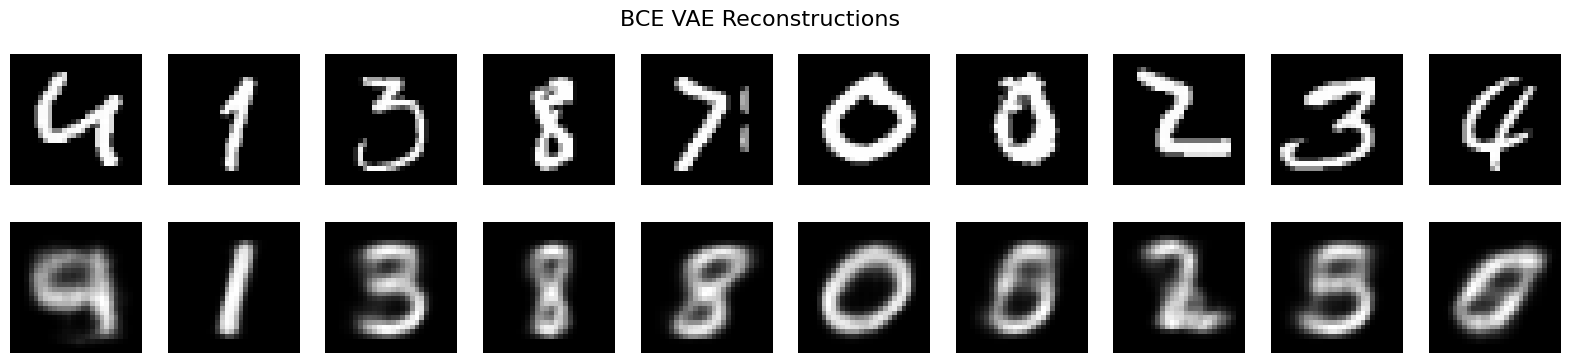

In [17]:
plot_reconstructions(vae_bce, "BCE")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


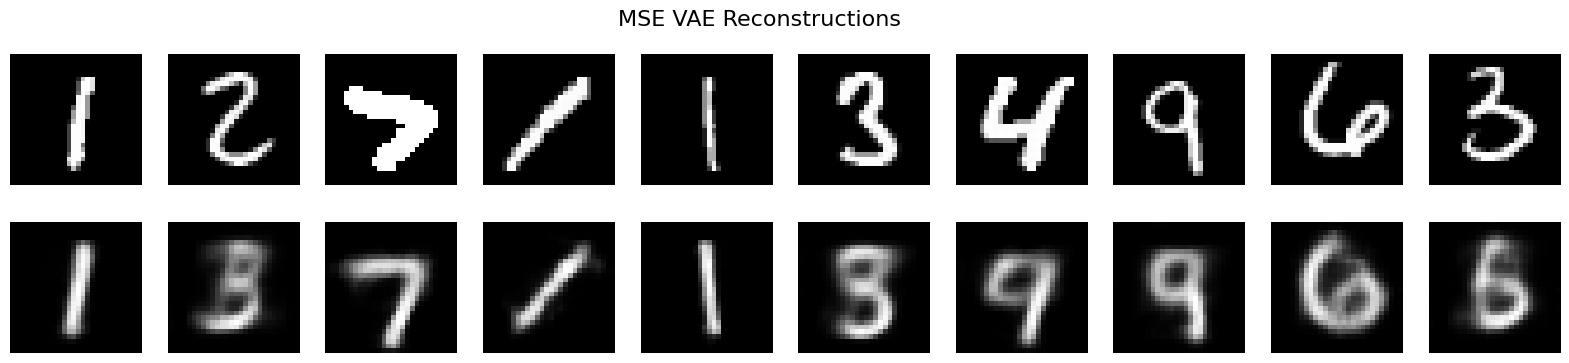

In [18]:
plot_reconstructions(vae_mse, "MSE")